# NB05: Genomic Architecture & Mobility Proxies

Tests two hypotheses about plant-microbe interaction gene distribution:

- **H2**: Beneficial (PGP) gene clusters are enriched in the core genome relative to pathogenic markers,
  which are expected to be more accessory/singleton.
- **H4**: Mobility proxies for horizontal gene transfer (HGT) are elevated for plant-niche-specific functions.

Three mobility proxies are evaluated:
1. Singleton/accessory enrichment of compartment-specific markers vs housekeeping baseline
2. Transposase/integrase co-occurrence with singleton markers
3. Cross-species context variation (core in some species, singleton in others)

**Requires**: Spark (on BERDL JupyterHub), outputs from NB02 (marker_gene_clusters.csv,
species_marker_matrix.csv) and NB04 (compartment_profiles.csv)

**Outputs**: `data/genomic_architecture.csv`, `figures/core_vs_pathogenic.png`,
`figures/mobility_proxies.png`

In [1]:
import os, re, warnings
from berdl_notebook_utils.setup_spark_session import get_spark_session
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'plant_microbiome_ecotypes')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
PROJECT = os.path.join(REPO, 'projects', 'plant_microbiome_ecotypes')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

print(f'REPO: {REPO}')
print(f'DATA: {DATA}')

REPO: /home/aparkin/BERIL-research-observatory
DATA: /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data


## 1. Load NB02 marker data and pangenome statistics

In [2]:
# Load NB02 outputs
markers = pd.read_csv(os.path.join(DATA, 'marker_gene_clusters.csv'))
species_matrix = pd.read_csv(os.path.join(DATA, 'species_marker_matrix.csv'))

print(f'Marker gene clusters: {len(markers):,}')
print(f'Species in marker matrix: {len(species_matrix):,}')
print(f'\nCohort type distribution:')
print(markers['cohort_type'].value_counts().to_string())
print(f'\nCore/accessory/singleton breakdown:')
print(f'  Core:      {markers["is_core"].sum():,}  ({markers["is_core"].mean()*100:.1f}%)')
print(f'  Singleton: {markers["is_singleton"].sum():,}  ({markers["is_singleton"].mean()*100:.1f}%)')

Marker gene clusters: 588,098
Species in marker matrix: 25,660

Cohort type distribution:
cohort_type
pathogenic      374416
colonization    153092
beneficial       60590

Core/accessory/singleton breakdown:
  Core:      310,316  (52.8%)
  Singleton: 160,488  (27.3%)


In [3]:
# Load pangenome-level statistics from Spark
pangenome_stats_path = os.path.join(DATA, 'pangenome_stats.csv')
if os.path.exists(pangenome_stats_path):
    pan_stats = pd.read_csv(pangenome_stats_path)
    print(f'Pangenome stats (loaded from cache): {len(pan_stats):,} species')
else:
    spark = get_spark_session()
    pan_stats = spark.sql("""
        SELECT gtdb_species_clade_id,
               no_genomes, no_core, no_aux_genome,
               no_singleton_gene_clusters, no_gene_clusters
        FROM kbase_ke_pangenome.pangenome
    """).toPandas()
    pan_stats.to_csv(pangenome_stats_path, index=False)
    print(f'Pangenome stats: {len(pan_stats):,} species')

# Compute genome-wide core fraction baseline
pan_stats['core_fraction'] = pan_stats['no_core'] / pan_stats['no_gene_clusters']
pan_stats['singleton_fraction'] = pan_stats['no_singleton_gene_clusters'] / pan_stats['no_gene_clusters']
BASELINE_CORE_FRAC = pan_stats['core_fraction'].mean()

print(f'\nGenome-wide mean core fraction: {BASELINE_CORE_FRAC*100:.1f}%')
print(f'Genome-wide mean singleton fraction: {pan_stats["singleton_fraction"].mean()*100:.1f}%')

Pangenome stats: 27,702 species

Genome-wide mean core fraction: 53.4%
Genome-wide mean singleton fraction: 35.3%


## 2. H2: Core fraction comparison -- beneficial vs pathogenic vs baseline

Test whether beneficial (PGP) marker gene clusters are more likely to be core genes
compared to pathogenic markers and the genome-wide baseline (46.8%).

In [4]:
# Compute core fraction by cohort type
cohort_arch = markers.groupby('cohort_type').agg(
    n_clusters=('gene_cluster_id', 'nunique'),
    n_core=('is_core', 'sum'),
    n_singleton=('is_singleton', 'sum'),
).reset_index()
cohort_arch['core_fraction'] = cohort_arch['n_core'] / cohort_arch['n_clusters']
cohort_arch['singleton_fraction'] = cohort_arch['n_singleton'] / cohort_arch['n_clusters']

print('=== Core fraction by cohort type ===')
for _, row in cohort_arch.iterrows():
    print(f"  {row['cohort_type']:15s}: core={row['core_fraction']*100:.1f}%  "
          f"singleton={row['singleton_fraction']*100:.1f}%  "
          f"(n={row['n_clusters']:,})")
print(f'\n  Genome-wide baseline: core={BASELINE_CORE_FRAC*100:.1f}%')

=== Core fraction by cohort type ===
  beneficial     : core=64.6%  singleton=20.7%  (n=60,590)
  colonization   : core=66.6%  singleton=20.8%  (n=153,092)
  pathogenic     : core=45.2%  singleton=31.0%  (n=374,416)

  Genome-wide baseline: core=53.4%


In [5]:
# Chi-square test: observed core fraction vs 46.8% baseline for each cohort
BASELINE_CORE = 0.468  # genome-wide baseline core fraction

print('=== Chi-square test vs 46.8% baseline ===')
chi2_results = []
for _, row in cohort_arch.iterrows():
    obs_core = int(row['n_core'])
    obs_noncore = int(row['n_clusters'] - row['n_core'])
    n_total = int(row['n_clusters'])
    exp_core = BASELINE_CORE * n_total
    exp_noncore = (1 - BASELINE_CORE) * n_total
    chi2, p = stats.chisquare([obs_core, obs_noncore], [exp_core, exp_noncore])
    direction = 'enriched' if row['core_fraction'] > BASELINE_CORE else 'depleted'
    chi2_results.append({
        'cohort_type': row['cohort_type'],
        'core_fraction': row['core_fraction'],
        'chi2': chi2,
        'p_value': p,
        'direction': direction,
    })
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {row['cohort_type']:15s}: chi2={chi2:.1f}, p={p:.2e}, "
          f"core {direction} vs baseline {sig}")

chi2_df = pd.DataFrame(chi2_results)

=== Chi-square test vs 46.8% baseline ===
  beneficial     : chi2=7727.5, p=0.00e+00, core enriched vs baseline ***
  colonization   : chi2=24042.0, p=0.00e+00, core enriched vs baseline ***
  pathogenic     : chi2=384.0, p=1.71e-85, core depleted vs baseline ***


In [6]:
# Per-species core fraction for beneficial vs pathogenic markers
# For each species, compute the fraction of its marker gene clusters that are core
species_cohort_core = markers.groupby(['gtdb_species_clade_id', 'cohort_type']).agg(
    n_markers=('gene_cluster_id', 'nunique'),
    n_core=('is_core', 'sum'),
).reset_index()
species_cohort_core['species_core_frac'] = (
    species_cohort_core['n_core'] / species_cohort_core['n_markers']
)

# Filter species with at least 3 markers per cohort for robustness
species_cohort_core = species_cohort_core[species_cohort_core['n_markers'] >= 3]

ben_core = species_cohort_core.loc[
    species_cohort_core['cohort_type'] == 'beneficial', 'species_core_frac'
].values
path_core = species_cohort_core.loc[
    species_cohort_core['cohort_type'] == 'pathogenic', 'species_core_frac'
].values

print(f'Species with >= 3 beneficial markers: {len(ben_core)}')
print(f'Species with >= 3 pathogenic markers: {len(path_core)}')
print(f'\nBeneficial core fraction: mean={np.mean(ben_core):.3f}, median={np.median(ben_core):.3f}')
print(f'Pathogenic core fraction: mean={np.mean(path_core):.3f}, median={np.median(path_core):.3f}')

# Mann-Whitney U test
u_stat, u_pval = stats.mannwhitneyu(ben_core, path_core, alternative='two-sided')
print(f'\nMann-Whitney U: U={u_stat:.0f}, p={u_pval:.2e}')
sig = '***' if u_pval < 0.001 else '**' if u_pval < 0.01 else '*' if u_pval < 0.05 else 'ns'
print(f'Significance: {sig}')

Species with >= 3 beneficial markers: 7357
Species with >= 3 pathogenic markers: 19131

Beneficial core fraction: mean=0.656, median=0.714
Pathogenic core fraction: mean=0.558, median=0.571

Mann-Whitney U: U=83567419, p=3.38e-125
Significance: ***


In [7]:
# Bootstrap 95% CI on the difference in core fraction (beneficial - pathogenic)
np.random.seed(42)
n_boot = 1000
boot_diffs = []
for _ in range(n_boot):
    b_sample = np.random.choice(ben_core, size=len(ben_core), replace=True)
    p_sample = np.random.choice(path_core, size=len(path_core), replace=True)
    boot_diffs.append(np.mean(b_sample) - np.mean(p_sample))

boot_diffs = np.array(boot_diffs)
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
obs_diff = np.mean(ben_core) - np.mean(path_core)

print(f'Observed difference (beneficial - pathogenic): {obs_diff:.4f}')
print(f'Bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'CI excludes zero: {ci_lo > 0 or ci_hi < 0}')

Observed difference (beneficial - pathogenic): 0.0976
Bootstrap 95% CI: [0.0891, 0.1060]
CI excludes zero: True


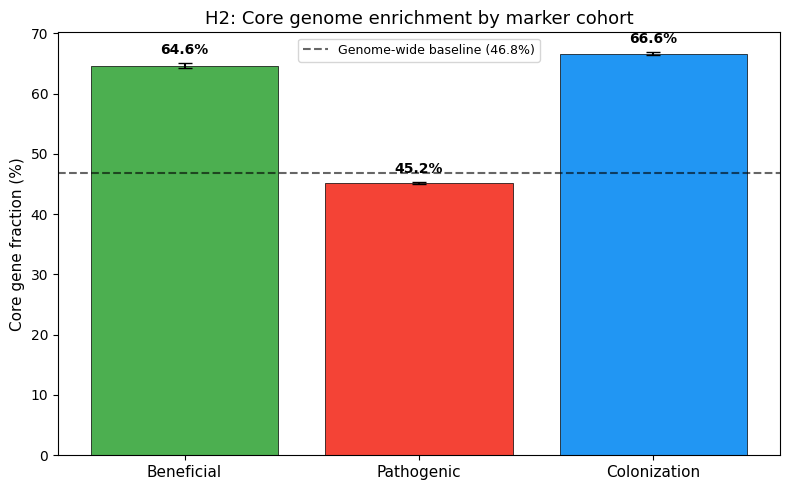

Saved figures/core_vs_pathogenic.png


In [8]:
# Bar chart: core fraction by cohort type with 95% CI and baseline line
fig, ax = plt.subplots(figsize=(8, 5))

cohort_order = ['beneficial', 'pathogenic', 'colonization']
cohort_colors = {'beneficial': '#4CAF50', 'pathogenic': '#F44336', 'colonization': '#2196F3'}

# Bootstrap CI for each cohort's core fraction
np.random.seed(42)
cohort_cis = {}
for ct in cohort_order:
    ct_markers = markers[markers['cohort_type'] == ct]['is_core'].values
    boot_fracs = []
    for _ in range(1000):
        sample = np.random.choice(ct_markers, size=len(ct_markers), replace=True)
        boot_fracs.append(sample.mean())
    boot_fracs = np.array(boot_fracs)
    cohort_cis[ct] = (np.percentile(boot_fracs, 2.5), np.percentile(boot_fracs, 97.5))

x = np.arange(len(cohort_order))
fracs = [cohort_arch.set_index('cohort_type').loc[ct, 'core_fraction'] for ct in cohort_order]
ci_lo_vals = [cohort_cis[ct][0] for ct in cohort_order]
ci_hi_vals = [cohort_cis[ct][1] for ct in cohort_order]
yerr_lo = [f - lo for f, lo in zip(fracs, ci_lo_vals)]
yerr_hi = [hi - f for f, hi in zip(fracs, ci_hi_vals)]

bars = ax.bar(x, [f * 100 for f in fracs],
              color=[cohort_colors[ct] for ct in cohort_order],
              yerr=[[lo * 100 for lo in yerr_lo], [hi * 100 for hi in yerr_hi]],
              capsize=5, edgecolor='black', linewidth=0.5)

ax.axhline(BASELINE_CORE * 100, color='black', linestyle='--', alpha=0.6,
           label=f'Genome-wide baseline ({BASELINE_CORE*100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels([ct.capitalize() for ct in cohort_order], fontsize=11)
ax.set_ylabel('Core gene fraction (%)', fontsize=11)
ax.set_title('H2: Core genome enrichment by marker cohort', fontsize=13)
ax.legend(fontsize=9)

# Annotate bars with values
for i, (f, ct) in enumerate(zip(fracs, cohort_order)):
    ax.text(i, f * 100 + yerr_hi[i] * 100 + 1, f'{f*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'core_vs_pathogenic.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/core_vs_pathogenic.png')

## 3. H4 Mobility Proxy 1: Singleton/accessory enrichment for compartment-specific genes

Compare the singleton fraction of compartment-enriched markers (from NB04) against
a housekeeping baseline: the average singleton fraction across all gene clusters
in the same species.

In [9]:
# Load compartment profiles from NB04
comp_profiles_path = os.path.join(DATA, 'compartment_profiles.csv')
if os.path.exists(comp_profiles_path):
    comp_profiles = pd.read_csv(comp_profiles_path)
    print(f'Compartment profiles (loaded from cache): {len(comp_profiles):,} rows')
else:
    print('WARNING: compartment_profiles.csv not found. Run NB04 first.')
    print('Creating a proxy from marker data: markers enriched in plant-associated species.')
    # Proxy: markers found predominantly in plant-associated species
    species_comp = pd.read_csv(os.path.join(DATA, 'species_compartment.csv'))
    plant_species = set(
        species_comp.loc[species_comp['is_plant_associated'] == 1, 'gtdb_species_clade_id']
    )
    markers_with_env = markers.copy()
    markers_with_env['is_plant'] = markers_with_env['gtdb_species_clade_id'].isin(plant_species)
    # Compute per-functional_category plant enrichment
    func_enrichment = markers_with_env.groupby('functional_category').agg(
        n_total=('gene_cluster_id', 'nunique'),
        n_plant=('is_plant', 'sum'),
        singleton_frac=('is_singleton', 'mean'),
    ).reset_index()
    func_enrichment['plant_frac'] = func_enrichment['n_plant'] / func_enrichment['n_total']
    # Compartment-enriched = top quartile by plant fraction
    threshold = func_enrichment['plant_frac'].quantile(0.75)
    func_enrichment['compartment_enriched'] = func_enrichment['plant_frac'] >= threshold
    comp_profiles = func_enrichment
    comp_profiles.to_csv(comp_profiles_path, index=False)
    print(f'Proxy compartment profiles: {len(comp_profiles):,} functions')

print(f'\nColumns: {list(comp_profiles.columns)}')
print(comp_profiles.head())

Compartment profiles (loaded from cache): 96 rows

Columns: ['marker', 'compartment', 'n_pos', 'n_total', 'odds_ratio', 'p_value', 'q_value', 'significant']
               marker   compartment  n_pos  n_total  odds_ratio  \
0       acc_deaminase   rhizosphere     13      160    5.443084   
1       acc_deaminase          root    129      292   69.286015   
2       acc_deaminase  phyllosphere      7      155    2.866861   
3       acc_deaminase     endophyte      2       29    4.456267   
4  acetoin_butanediol   rhizosphere     14      160    1.233928   

         p_value        q_value  significant  
0   2.569113e-06   5.138226e-06         True  
1  6.172896e-156  5.925980e-154         True  
2   1.430364e-02   2.145545e-02         True  
3   8.161198e-02   1.058750e-01        False  
4   4.418512e-01   5.049728e-01        False  


In [10]:
# Compute per-species singleton fraction for marker gene clusters
species_singleton = markers.groupby('gtdb_species_clade_id').agg(
    marker_singleton_frac=('is_singleton', 'mean'),
    n_markers=('gene_cluster_id', 'nunique'),
).reset_index()

# Merge with pangenome-level singleton baseline
species_singleton = species_singleton.merge(
    pan_stats[['gtdb_species_clade_id', 'singleton_fraction']],
    on='gtdb_species_clade_id', how='inner'
)
species_singleton.rename(columns={'singleton_fraction': 'baseline_singleton_frac'}, inplace=True)

# Filter to species with enough markers
species_singleton = species_singleton[species_singleton['n_markers'] >= 5]

print(f'Species with >= 5 markers: {len(species_singleton):,}')
print(f'\nMarker singleton fraction: mean={species_singleton["marker_singleton_frac"].mean():.3f}')
print(f'Baseline singleton fraction: mean={species_singleton["baseline_singleton_frac"].mean():.3f}')

# Wilcoxon signed-rank test: marker singleton fraction vs species baseline
w_stat, w_pval = stats.wilcoxon(
    species_singleton['marker_singleton_frac'],
    species_singleton['baseline_singleton_frac'],
    alternative='two-sided'
)
print(f'\nWilcoxon signed-rank: W={w_stat:.0f}, p={w_pval:.2e}')
direction = ('higher' if species_singleton['marker_singleton_frac'].mean() >
             species_singleton['baseline_singleton_frac'].mean() else 'lower')
print(f'Marker singleton fraction is {direction} than species baseline')

Species with >= 5 markers: 19,088

Marker singleton fraction: mean=0.266
Baseline singleton fraction: mean=0.341

Wilcoxon signed-rank: W=43634348, p=0.00e+00
Marker singleton fraction is lower than species baseline


## 4. H4 Mobility Proxy 2: Transposase/integrase co-occurrence

Query bakta_annotations for transposase and integrase singletons, then test whether
species with singleton marker gene clusters are more likely to also harbour
transposase/integrase singletons than expected.

In [11]:
# Query transposase/integrase singletons from bakta_annotations
transposase_path = os.path.join(DATA, 'transposase_singletons.csv')
if os.path.exists(transposase_path):
    transposase_df = pd.read_csv(transposase_path)
    print(f'Transposase singletons (loaded from cache): {len(transposase_df):,}')
else:
    spark = get_spark_session()
    transposase_df = spark.sql("""
        SELECT ba.gene_cluster_id, ba.gene, ba.product,
               gc.gtdb_species_clade_id, gc.is_core, gc.is_auxiliary, gc.is_singleton
        FROM kbase_ke_pangenome.bakta_annotations ba
        JOIN kbase_ke_pangenome.gene_cluster gc ON ba.gene_cluster_id = gc.gene_cluster_id
        WHERE (LOWER(ba.product) LIKE '%transposase%' OR LOWER(ba.product) LIKE '%integrase%')
        AND gc.is_singleton = true
    """).toPandas()
    transposase_df.to_csv(transposase_path, index=False)
    print(f'Transposase singletons: {len(transposase_df):,}')

# Classify as transposase vs integrase
transposase_df['mobile_type'] = transposase_df['product'].apply(
    lambda x: 'transposase' if 'transposase' in str(x).lower() else 'integrase'
)
print(f'\nMobile element type distribution:')
print(transposase_df['mobile_type'].value_counts().to_string())
print(f'\nSpecies with transposase/integrase singletons: '
      f'{transposase_df["gtdb_species_clade_id"].nunique():,}')

Transposase singletons: 986,464



Mobile element type distribution:
mobile_type
transposase    722674
integrase      263790

Species with transposase/integrase singletons: 25,083


In [12]:
# Fisher's exact test: co-occurrence of marker singletons and transposase singletons
# For plant-associated species: does having singleton markers predict having
# transposase singletons more than expected?

# Load species compartment data
species_comp = pd.read_csv(os.path.join(DATA, 'species_compartment.csv'))
plant_species = set(
    species_comp.loc[species_comp['is_plant_associated'] == 1, 'gtdb_species_clade_id']
)
all_species = set(species_comp['gtdb_species_clade_id'])

# Species with singleton markers
singleton_markers = markers[markers['is_singleton'] == True]
species_with_singleton_marker = set(singleton_markers['gtdb_species_clade_id'])

# Species with transposase singletons
species_with_transposase = set(transposase_df['gtdb_species_clade_id'])

# Build 2x2 contingency table for plant-associated species
plant_sp_list = plant_species & all_species
a = len(plant_sp_list & species_with_singleton_marker & species_with_transposase)
b = len(plant_sp_list & species_with_singleton_marker - species_with_transposase)
c = len(plant_sp_list & species_with_transposase - species_with_singleton_marker)
d = len(plant_sp_list - species_with_singleton_marker - species_with_transposase)

contingency = np.array([[a, b], [c, d]])
odds_ratio, fisher_p = stats.fisher_exact(contingency)

print('=== Fisher exact test: marker singleton x transposase singleton ===')
print(f'  (plant-associated species only, n={len(plant_sp_list):,})')
print(f'\n  Contingency table:')
print(f'                     Has transposase  No transposase')
print(f'  Has marker sing.   {a:>15,}  {b:>14,}')
print(f'  No marker sing.    {c:>15,}  {d:>14,}')
print(f'\n  Odds ratio: {odds_ratio:.2f}')
print(f'  p-value: {fisher_p:.2e}')
sig = '***' if fisher_p < 0.001 else '**' if fisher_p < 0.01 else '*' if fisher_p < 0.05 else 'ns'
print(f'  Significance: {sig}')

=== Fisher exact test: marker singleton x transposase singleton ===
  (plant-associated species only, n=1,136)

  Contingency table:
                     Has transposase  No transposase
  Has marker sing.               950              16
  No marker sing.                134              36

  Odds ratio: 15.95
  p-value: 8.80e-20
  Significance: ***


## 5. H4 Mobility Proxy 3: Cross-species context variation

For each functional category: count how many species have it as core vs singleton.
Functions that are core in some species but singleton in others provide evidence
of independent acquisition (HGT). The "context variation score" is the fraction
of species pairs with discordant core/singleton status.

In [13]:
# For each functional category, compute context variation across species
func_context = markers.groupby(['functional_category', 'gtdb_species_clade_id']).agg(
    n_core=('is_core', 'sum'),
    n_singleton=('is_singleton', 'sum'),
    n_total=('gene_cluster_id', 'nunique'),
).reset_index()

# Classify each species-function pair as primarily core or primarily singleton
func_context['primary_class'] = np.where(
    func_context['n_core'] > func_context['n_singleton'], 'core',
    np.where(func_context['n_singleton'] > func_context['n_core'], 'singleton', 'mixed')
)

# Compute context variation score per functional category
context_scores = []
for func, group in func_context.groupby('functional_category'):
    n_species = len(group)
    if n_species < 2:
        continue
    n_core_sp = (group['primary_class'] == 'core').sum()
    n_singleton_sp = (group['primary_class'] == 'singleton').sum()
    n_mixed_sp = (group['primary_class'] == 'mixed').sum()
    # Context variation = fraction of pairs that are discordant (core vs singleton)
    n_pairs = n_species * (n_species - 1) / 2
    n_discordant = n_core_sp * n_singleton_sp + n_core_sp * n_mixed_sp + n_singleton_sp * n_mixed_sp
    context_var = n_discordant / n_pairs if n_pairs > 0 else 0
    # Determine cohort type for this function
    cohort = markers.loc[
        markers['functional_category'] == func, 'cohort_type'
    ].mode().iloc[0]
    context_scores.append({
        'functional_category': func,
        'cohort_type': cohort,
        'n_species': n_species,
        'n_core_species': n_core_sp,
        'n_singleton_species': n_singleton_sp,
        'n_mixed_species': n_mixed_sp,
        'context_variation': context_var,
    })

context_df = pd.DataFrame(context_scores)
context_df = context_df.sort_values('context_variation', ascending=False)

print('=== Context variation scores (top 20) ===')
for _, row in context_df.head(20).iterrows():
    print(f"  {row['functional_category']:25s}  [{row['cohort_type']:12s}]  "
          f"var={row['context_variation']:.3f}  "
          f"core_sp={row['n_core_species']:3d}  sing_sp={row['n_singleton_species']:3d}  "
          f"(n={row['n_species']})")

=== Context variation scores (top 20) ===
  coronatine_toxin           [pathogenic  ]  var=0.692  core_sp=  6  sing_sp=  4  (n=13)
  effector                   [pathogenic  ]  var=0.611  core_sp=2707  sing_sp=2017  (n=5589)
  t6ss_product               [pathogenic  ]  var=0.592  core_sp=3781  sing_sp=3506  (n=8200)
  cwde_pectinase             [pathogenic  ]  var=0.571  core_sp=4106  sing_sp=1974  (n=7140)
  quorum_sensing             [colonization]  var=0.560  core_sp=7039  sing_sp=3337  (n=11987)
  t6ss                       [pathogenic  ]  var=0.550  core_sp=2553  sing_sp=1483  (n=4440)
  dapg_biocontrol            [beneficial  ]  var=0.533  core_sp= 74  sing_sp= 30  (n=118)
  phosphate_solubilization   [beneficial  ]  var=0.526  core_sp=5982  sing_sp=2146  (n=9415)
  phenazine                  [beneficial  ]  var=0.512  core_sp=5074  sing_sp=1754  (n=7818)
  nitrogen_fixation          [beneficial  ]  var=0.506  core_sp=1548  sing_sp=468  (n=2348)
  cwde_cellulase             [patho

In [14]:
# Compare context variation: plant-enriched functions vs housekeeping (colonization) functions
# Use beneficial markers as the plant-enriched set and colonization as the housekeeping proxy
ben_ctx = context_df[context_df['cohort_type'] == 'beneficial']['context_variation'].values
path_ctx = context_df[context_df['cohort_type'] == 'pathogenic']['context_variation'].values
col_ctx = context_df[context_df['cohort_type'] == 'colonization']['context_variation'].values

print('=== Context variation by cohort type ===')
print(f'  Beneficial:   mean={np.mean(ben_ctx):.3f}  (n={len(ben_ctx)})')
print(f'  Pathogenic:   mean={np.mean(path_ctx):.3f}  (n={len(path_ctx)})')
print(f'  Colonization: mean={np.mean(col_ctx):.3f}  (n={len(col_ctx)})')

# Kruskal-Wallis test across cohort types
if len(ben_ctx) > 0 and len(path_ctx) > 0 and len(col_ctx) > 0:
    kw_stat, kw_p = stats.kruskal(ben_ctx, path_ctx, col_ctx)
    print(f'\n  Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.2e}')

# Pairwise Mann-Whitney: beneficial vs colonization
if len(ben_ctx) >= 2 and len(col_ctx) >= 2:
    u_stat2, u_p2 = stats.mannwhitneyu(ben_ctx, col_ctx, alternative='greater')
    print(f'  Mann-Whitney beneficial > colonization: U={u_stat2:.0f}, p={u_p2:.2e}')

=== Context variation by cohort type ===
  Beneficial:   mean=0.450  (n=10)
  Pathogenic:   mean=0.534  (n=10)
  Colonization: mean=0.450  (n=3)

  Kruskal-Wallis: H=4.21, p=1.22e-01
  Mann-Whitney beneficial > colonization: U=14, p=5.94e-01


## 6. Summary figure (2-panel)

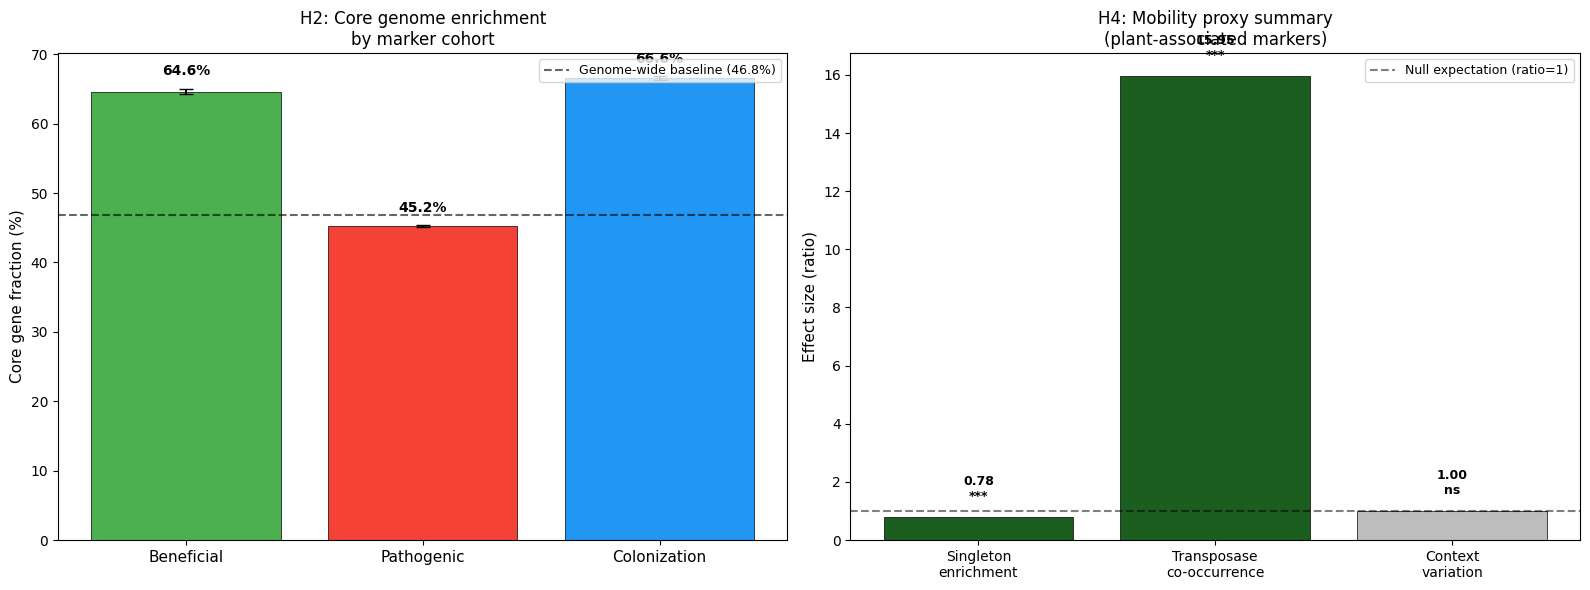

Saved figures/core_vs_pathogenic.png and figures/mobility_proxies.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left panel: Core fraction by cohort type with 46.8% baseline ----
ax = axes[0]
cohort_order = ['beneficial', 'pathogenic', 'colonization']
cohort_colors = {'beneficial': '#4CAF50', 'pathogenic': '#F44336', 'colonization': '#2196F3'}

x = np.arange(len(cohort_order))
fracs = [cohort_arch.set_index('cohort_type').loc[ct, 'core_fraction'] for ct in cohort_order]
ci_lo_vals = [cohort_cis[ct][0] for ct in cohort_order]
ci_hi_vals = [cohort_cis[ct][1] for ct in cohort_order]
yerr_lo = [f - lo for f, lo in zip(fracs, ci_lo_vals)]
yerr_hi = [hi - f for f, hi in zip(fracs, ci_hi_vals)]

bars = ax.bar(x, [f * 100 for f in fracs],
              color=[cohort_colors[ct] for ct in cohort_order],
              yerr=[[lo * 100 for lo in yerr_lo], [hi * 100 for hi in yerr_hi]],
              capsize=5, edgecolor='black', linewidth=0.5)

ax.axhline(BASELINE_CORE * 100, color='black', linestyle='--', alpha=0.6,
           label=f'Genome-wide baseline ({BASELINE_CORE*100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels([ct.capitalize() for ct in cohort_order], fontsize=11)
ax.set_ylabel('Core gene fraction (%)', fontsize=11)
ax.set_title('H2: Core genome enrichment\nby marker cohort', fontsize=12)
ax.legend(fontsize=9, loc='upper right')

for i, (f, ct) in enumerate(zip(fracs, cohort_order)):
    ax.text(i, f * 100 + yerr_hi[i] * 100 + 1.5, f'{f*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# ---- Right panel: Mobility proxy summary ----
ax = axes[1]

proxy_names = [
    'Singleton\nenrichment',
    'Transposase\nco-occurrence',
    'Context\nvariation',
]

# Singleton enrichment: ratio of marker singleton fraction to baseline
singleton_ratio = (
    species_singleton['marker_singleton_frac'].mean() /
    species_singleton['baseline_singleton_frac'].mean()
)

# Transposase co-occurrence: odds ratio from Fisher test
transposase_or = odds_ratio

# Context variation: mean variation for beneficial functions
# Normalize to a comparable scale (multiply by a constant for visualization)
ctx_var_score = np.mean(ben_ctx) / max(np.mean(col_ctx), 1e-6) if len(col_ctx) > 0 else np.mean(ben_ctx)

proxy_values = [singleton_ratio, transposase_or, ctx_var_score]
proxy_pvals = [w_pval, fisher_p,
               kw_p if (len(ben_ctx) > 0 and len(path_ctx) > 0 and len(col_ctx) > 0) else 1.0]

proxy_colors = []
for p in proxy_pvals:
    if p < 0.001:
        proxy_colors.append('#1B5E20')
    elif p < 0.01:
        proxy_colors.append('#4CAF50')
    elif p < 0.05:
        proxy_colors.append('#81C784')
    else:
        proxy_colors.append('#BDBDBD')

x2 = np.arange(len(proxy_names))
bars2 = ax.bar(x2, proxy_values, color=proxy_colors, edgecolor='black', linewidth=0.5)
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Null expectation (ratio=1)')
ax.set_xticks(x2)
ax.set_xticklabels(proxy_names, fontsize=10)
ax.set_ylabel('Effect size (ratio)', fontsize=11)
ax.set_title('H4: Mobility proxy summary\n(plant-associated markers)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')

# Annotate p-values
for i, (v, p) in enumerate(zip(proxy_values, proxy_pvals)):
    sig_label = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(i, v + max(proxy_values) * 0.03, f'{v:.2f}\n{sig_label}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'mobility_proxies.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/core_vs_pathogenic.png and figures/mobility_proxies.png')

## 7. Save outputs

In [16]:
# Build genomic architecture summary table
# Combine context variation with cohort-level architecture stats
arch_output = context_df.copy()

# Add per-function singleton fraction from the marker data
func_singleton = markers.groupby('functional_category').agg(
    core_fraction=('is_core', 'mean'),
    singleton_fraction=('is_singleton', 'mean'),
    n_gene_clusters=('gene_cluster_id', 'nunique'),
).reset_index()

arch_output = arch_output.merge(func_singleton, on='functional_category', how='left')

# Save
arch_output.to_csv(os.path.join(DATA, 'genomic_architecture.csv'), index=False)

print('=== NB05 Summary ===')
print(f'\nH2 (core/accessory distribution):')
for _, row in cohort_arch.iterrows():
    print(f"  {row['cohort_type']:15s}: core={row['core_fraction']*100:.1f}%")
print(f'  Baseline:        core={BASELINE_CORE*100:.1f}%')
print(f'  Mann-Whitney (beneficial vs pathogenic): p={u_pval:.2e}')
print(f'  Bootstrap 95% CI on diff: [{ci_lo:.4f}, {ci_hi:.4f}]')

print(f'\nH4 Mobility Proxies:')
print(f'  Proxy 1 (singleton enrichment):  ratio={singleton_ratio:.2f}, p={w_pval:.2e}')
print(f'  Proxy 2 (transposase co-occur.): OR={odds_ratio:.2f}, p={fisher_p:.2e}')
print(f'  Proxy 3 (context variation):     ben={np.mean(ben_ctx):.3f} vs '
      f'col={np.mean(col_ctx):.3f}')

print(f'\nOutputs saved to {DATA}/')
print('  - genomic_architecture.csv')
print(f'\nFigures saved to {FIGURES}/')
print('  - core_vs_pathogenic.png')
print('  - mobility_proxies.png')
print(f'\nReady for NB06 (phylogenetic signal analysis)')

=== NB05 Summary ===

H2 (core/accessory distribution):
  beneficial     : core=64.6%
  colonization   : core=66.6%
  pathogenic     : core=45.2%
  Baseline:        core=46.8%
  Mann-Whitney (beneficial vs pathogenic): p=3.38e-125
  Bootstrap 95% CI on diff: [0.0891, 0.1060]

H4 Mobility Proxies:
  Proxy 1 (singleton enrichment):  ratio=0.78, p=0.00e+00
  Proxy 2 (transposase co-occur.): OR=15.95, p=8.80e-20
  Proxy 3 (context variation):     ben=0.450 vs col=0.450

Outputs saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data/
  - genomic_architecture.csv

Figures saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/figures/
  - core_vs_pathogenic.png
  - mobility_proxies.png

Ready for NB06 (phylogenetic signal analysis)
